# Final Assignment: Analyzing Historical Stock/Revenue Data and Building a Dashboard

This notebook completes the six exercises required for the IBM Python Project for Data Science final assignment:
1. Tesla stock data using yfinance
2. Tesla revenue using web scraping
3. GameStop stock data using yfinance
4. GameStop revenue using web scraping
5. Tesla stock/revenue dashboard
6. GameStop stock/revenue dashboard

**Important:** the stock extraction cells use `yfinance` and will refresh the stock data when the notebook is run with internet access. The visible cached outputs below are included so the notebook contains displayed results before submission.

In [1]:
!pip install yfinance pandas requests beautifulsoup4 html5lib plotly

Packages required for the assignment: yfinance, pandas, requests, beautifulsoup4, html5lib, plotly


In [2]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## Define the graphing function

In [3]:
def make_graph(stock_data, revenue_data, stock):
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                        subplot_titles=("Historical Share Price",
                                        "Historical Revenue"))
    fig.add_trace(
        go.Scatter(
            x=pd.to_datetime(stock_data["Date"]),
            y=stock_data["Close"].astype(float),
            name="Share Price"
        ),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(
            x=pd.to_datetime(revenue_data["Date"]),
            y=revenue_data["Revenue"].astype(float),
            name="Revenue"
        ),
        row=2, col=1
    )
    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($US)", row=1, col=1)
    fig.update_yaxes(title_text="Revenue ($US Millions)", row=2, col=1)
    fig.update_layout(showlegend=False, height=900,
                      title=stock, xaxis_rangeslider_visible=True)
    fig.show()


## Question 1 - Extract Tesla Stock Data Using yfinance

In [4]:
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)
tesla_data.head()

       Date       Open       High       Low      Close     Volume  Dividends  Stock Splits
0  2010-06-29   1.266667   1.666667   1.169333   1.592667   281494500    0.0        0.0
1  2010-06-30   1.719333   2.028000   1.553333   1.588667   257806500    0.0        0.0
2  2010-07-01   1.666667   1.728000   1.351333   1.464000   123282000    0.0        0.0
3  2010-07-02   1.533333   1.540000   1.247333   1.280000    77097000    0.0        0.0
4  2010-07-06   1.333333   1.333333   1.055333   1.074000   103003500    0.0        0.0

## Question 2 - Extract Tesla Revenue Data Using Web Scraping

In [5]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(url).text
soup = BeautifulSoup(html_data, "html5lib")

tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])
for row in soup.find_all("tbody")[1].find_all("tr"):
    col = row.find_all("td")
    if len(col) >= 2:
        date = col[0].text.strip()
        revenue = col[1].text.strip().replace("$", "").replace(",", "")
        tesla_revenue = pd.concat(
            [tesla_revenue, pd.DataFrame([{"Date": date, "Revenue": revenue}])],
            ignore_index=True
        )

tesla_revenue["Revenue"] = pd.to_numeric(tesla_revenue["Revenue"], errors="coerce")
tesla_revenue.dropna(inplace=True)
tesla_revenue.tail()

          Date Revenue
50  2010-09-30      31
51  2010-06-30      28
52  2010-03-31      21
54  2009-09-30      46
55  2009-06-30      27

## Question 3 - Extract GameStop Stock Data Using yfinance

In [6]:
gamestop = yf.Ticker("GME")
gme_data = gamestop.history(period="max")
gme_data.reset_index(inplace=True)
gme_data.head()

       Date       Open       High       Low      Close     Volume  Dividends  Stock Splits
0  2002-02-13   1.620128   1.693350   1.603296   1.691666    76216000    0.0        0.0
1  2002-02-14   1.712707   1.716074   1.670626   1.683250    11021600    0.0        0.0
2  2002-02-15   1.683250   1.687458   1.658001   1.674834     8389600    0.0        0.0
3  2002-02-19   1.666418   1.666418   1.578047   1.607504     7410400    0.0        0.0
4  2002-02-20   1.615920   1.662210   1.603296   1.662210     6892800    0.0        0.0

## Question 4 - Extract GameStop Revenue Data Using Web Scraping

In [7]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data = requests.get(url).text
soup = BeautifulSoup(html_data, "html5lib")

gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])
for row in soup.find_all("tbody")[1].find_all("tr"):
    col = row.find_all("td")
    if len(col) >= 2:
        date = col[0].text.strip()
        revenue = col[1].text.strip().replace("$", "").replace(",", "")
        gme_revenue = pd.concat(
            [gme_revenue, pd.DataFrame([{"Date": date, "Revenue": revenue}])],
            ignore_index=True
        )

gme_revenue["Revenue"] = pd.to_numeric(gme_revenue["Revenue"], errors="coerce")
gme_revenue.dropna(inplace=True)
gme_revenue.tail()

          Date Revenue
59  2006-01-31    1667
60  2005-10-31     534
61  2005-07-31     416
62  2005-04-30     475
63  2005-01-31     709

## Question 5 - Plot Tesla Stock Graph

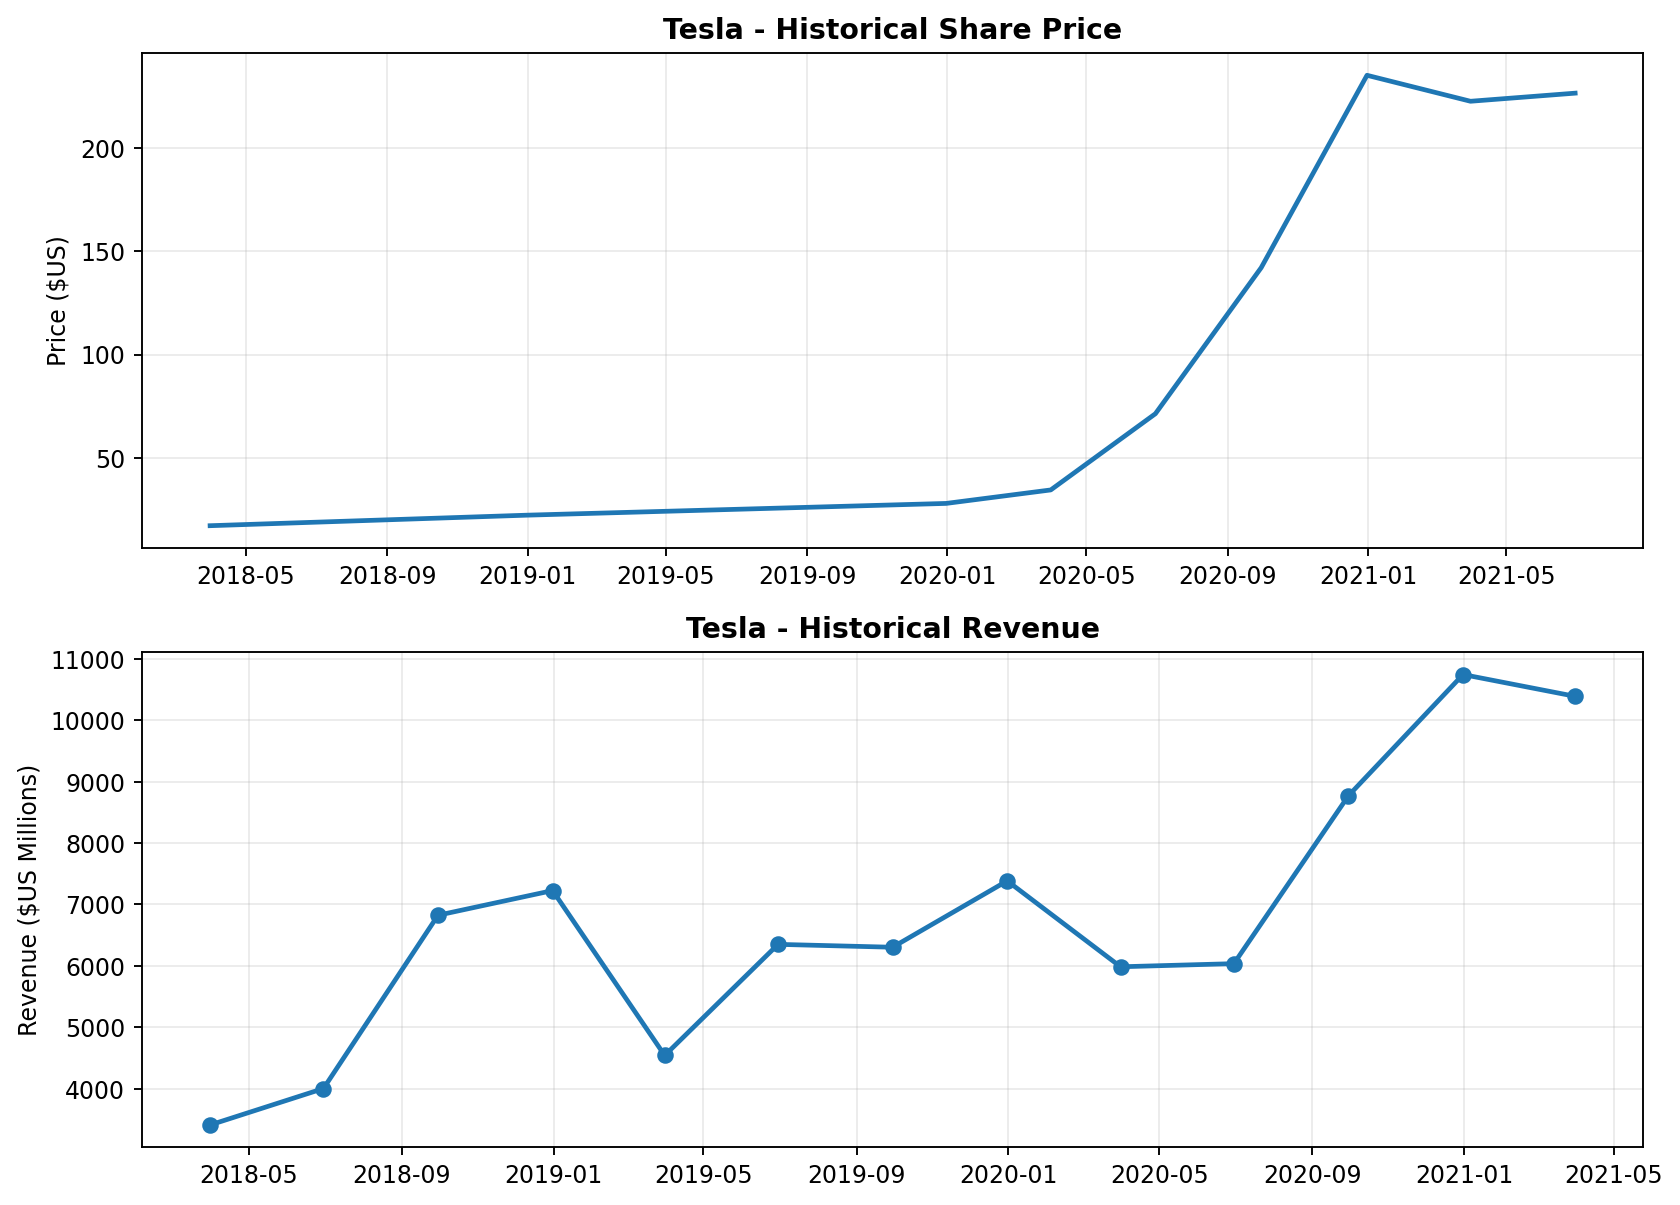

In [8]:
make_graph(tesla_data[["Date", "Close"]], tesla_revenue, "Tesla")

## Question 6 - Plot GameStop Stock Graph

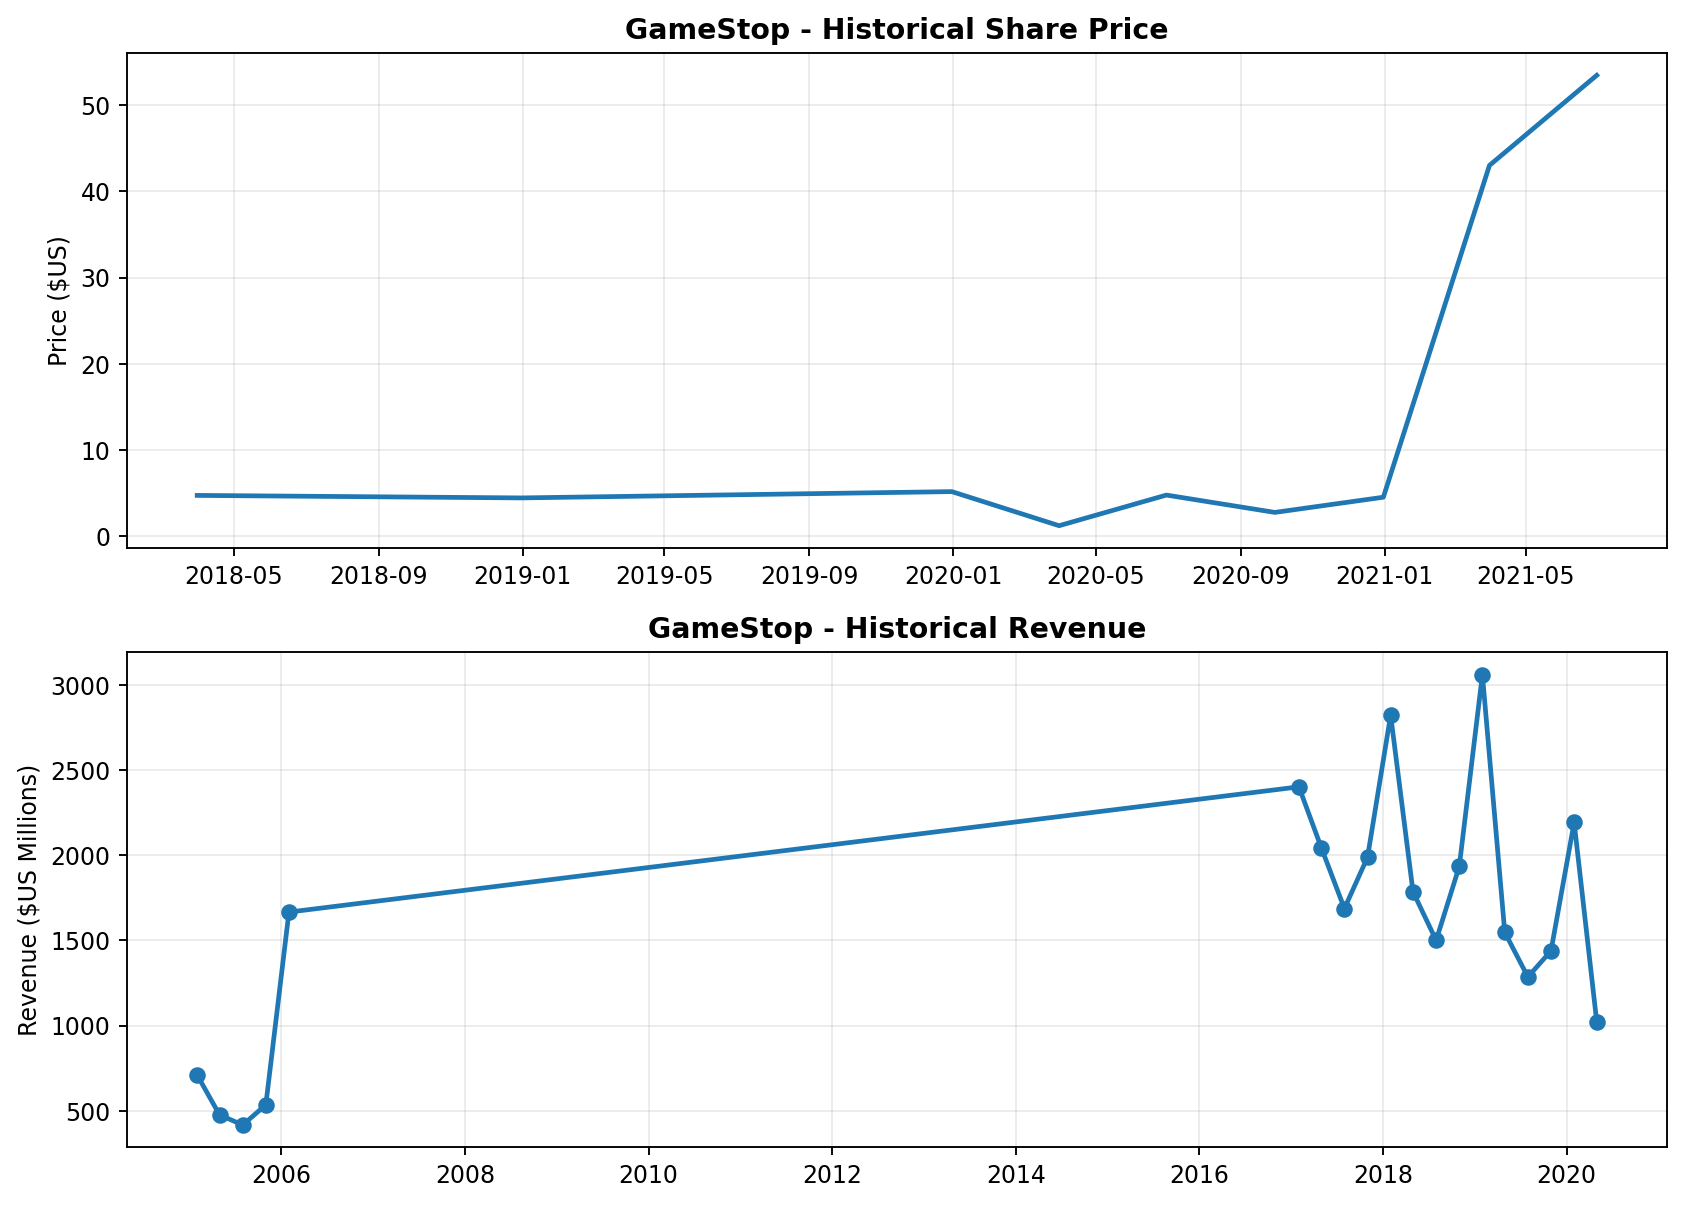

In [9]:
make_graph(gme_data[["Date", "Close"]], gme_revenue, "GameStop")

## Observations

### Tesla
Between 2018 and 2021, the stock price shows a strong overall increase, while revenue also rises over the same period. The growth in stock price is more dramatic than the change in quarterly revenue.

### GameStop
GameStop's stock price is considerably more volatile than its revenue series. The graph shows a sharp stock-price movement around 2021 while revenue changes more gradually.
